In [7]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ===== 中文显示设置 =====
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 例 6-4 的列联表
table = [[37, 27],
         [39, 21]]

# 默认 correction=True → 用 Yates 修正，得到书上 0.4054
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"带 Yates 修正: chi2={chi2:.4f}, p={p:.4f}, dof={dof}")
print("期望频数:\n", expected)

# 关掉修正 → 得到 0.6743
chi2_nc, p_nc, _, _ = stats.chi2_contingency(table, correction=False)
print(f"无修正:       chi2={chi2_nc:.4f}, p={p_nc:.4f}")

带 Yates 修正: chi2=0.4054, p=0.5243, dof=1
期望频数:
 [[39.22580645 24.77419355]
 [36.77419355 23.22580645]]
无修正:       chi2=0.6743, p=0.4116


手动计算结果：
  β₁ = 2.9303,  β₀ = 0.2569
  回归方程:  ŷ = 0.2569 + 2.9303x
  相关系数 r = 0.9911,  判定系数 R² = 0.9823

scipy 验证：
  β₁ = 2.9303,  β₀ = 0.2569
  r  = 0.9911,  R² = 0.9823


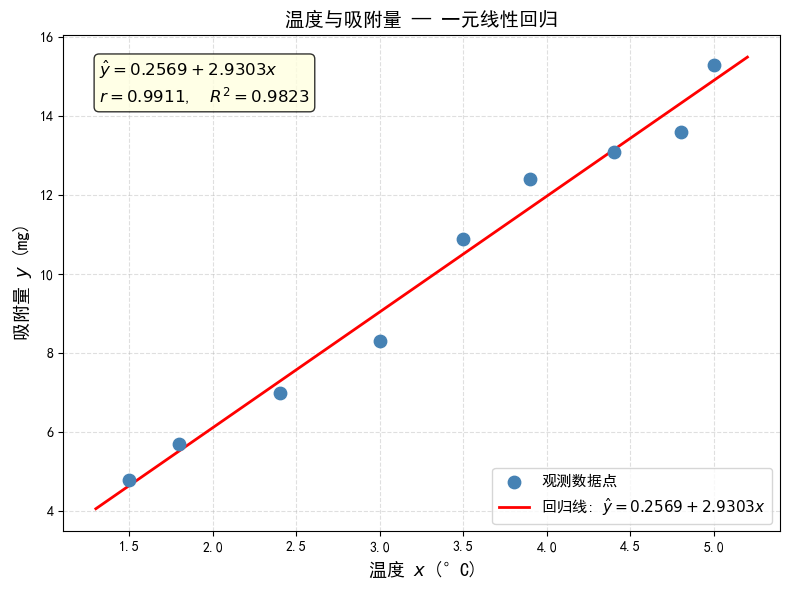

In [12]:
# ===== 数据 =====
x = np.array([1.5, 1.8, 2.4, 3.0, 3.5, 3.9, 4.4, 4.8, 5.0])
y = np.array([4.8, 5.7, 7.0, 8.3, 10.9, 12.4, 13.1, 13.6, 15.3])

# ===== 手动计算 =====
n = len(x)
x_bar = np.mean(x)
y_bar = np.mean(y)
Sxx = np.sum((x - x_bar)**2)
Syy = np.sum((y - y_bar)**2)
Sxy = np.sum((x - x_bar) * (y - y_bar))

beta1 = Sxy / Sxx
beta0 = y_bar - beta1 * x_bar
r = Sxy / np.sqrt(Sxx * Syy)
R2 = r**2

print(f"手动计算结果：")
print(f"  β₁ = {beta1:.4f},  β₀ = {beta0:.4f}")
print(f"  回归方程:  ŷ = {beta0:.4f} + {beta1:.4f}x")
print(f"  相关系数 r = {r:.4f},  判定系数 R² = {R2:.4f}")

# ===== scipy 验证 =====
res = stats.linregress(x, y)
print(f"\nscipy 验证：")
print(f"  β₁ = {res.slope:.4f},  β₀ = {res.intercept:.4f}")
print(f"  r  = {res.rvalue:.4f},  R² = {res.rvalue**2:.4f}")

# ===== 绘图（关键修复：使用 LaTeX 数学模式）=====
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='steelblue', s=80, label='观测数据点', zorder=5)

# 回归直线
x_fit = np.linspace(x.min() - 0.2, x.max() + 0.2, 200)
y_fit = beta0 + beta1 * x_fit
plt.plot(x_fit, y_fit, 'r-', linewidth=2,
         label=rf'回归线: $\hat{{y}} = {beta0:.4f} + {beta1:.4f}x$')

# 标注框（LaTeX 数学模式避免 SimHei 缺失 glyph）
eq_text = (rf'$\hat{{y}} = {beta0:.4f} + {beta1:.4f}x$' + '\n'
           + rf'$r = {r:.4f}$,  $R^{{2}} = {R2:.4f}$')
plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.xlabel('温度 $x$ (°C)', fontsize=13)
plt.ylabel('吸附量 $y$ (mg)', fontsize=13)
plt.title('温度与吸附量 — 一元线性回归', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('demo_regression.png', dpi=200)
plt.show()

总点数:    10000
圆内点数:  7837
π 估计值:  3.134800
π 真实值:  3.141593
绝对误差:  0.006793


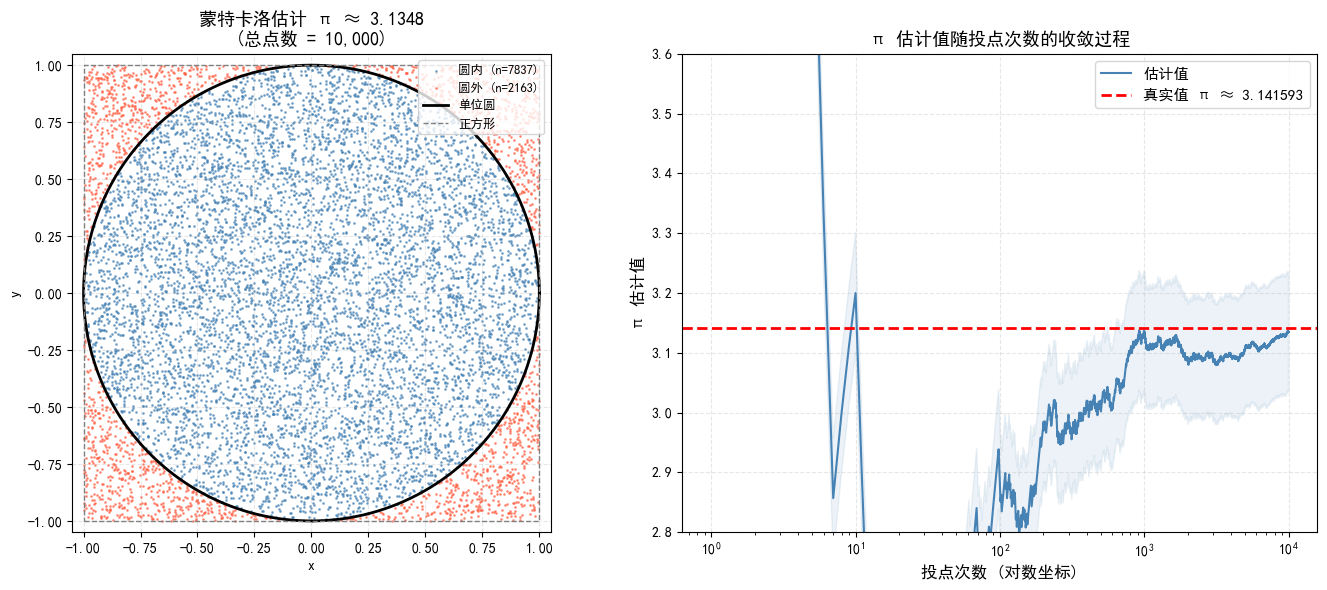


===== 不同投点量的精度 =====
N =      100:  π ≈ 3.320000   误差 = 0.178407   相对误差 = 5.6789%
N =     1000:  π ≈ 3.080000   误差 = 0.061593   相对误差 = 1.9606%
N =    10000:  π ≈ 3.167600   误差 = 0.026007   相对误差 = 0.8278%
N =   100000:  π ≈ 3.135880   误差 = 0.005713   相对误差 = 0.1818%
N =  1000000:  π ≈ 3.140232   误差 = 0.001361   相对误差 = 0.0433%


In [10]:
# ===== 蒙特卡洛估计 π =====
np.random.seed(42)          # 固定随机种子，保证可复现
n_total = 10000             # 总投点数

# 在 [-1, 1] 上均匀随机采样
x = np.random.uniform(-1, 1, n_total)
y = np.random.uniform(-1, 1, n_total)

# 判断是否在单位圆内：x² + y² <= 1
inside = (x**2 + y**2) <= 1
n_inside = np.sum(inside)

pi_estimate = 4 * n_inside / n_total

print(f"总点数:    {n_total}")
print(f"圆内点数:  {n_inside}")
print(f"π 估计值:  {pi_estimate:.6f}")
print(f"π 真实值:  {np.pi:.6f}")
print(f"绝对误差:  {abs(pi_estimate - np.pi):.6f}")

# ===== 收敛曲线 =====
# 计算前缀和，观察 π 估计值随点数增加的变化
cum_inside = np.cumsum(inside)
cum_n = np.arange(1, n_total + 1)
cum_pi = 4 * cum_inside / cum_n

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- 左图：散点图 ---
ax1.set_aspect('equal')
# 圆内点用蓝色，圆外点用红色
ax1.scatter(x[inside],  y[inside],  c='steelblue', s=1, label=f'圆内 (n={n_inside})', alpha=0.6)
ax1.scatter(x[~inside], y[~inside], c='tomato',    s=1, label=f'圆外 (n={n_total-n_inside})', alpha=0.6)

# 绘制单位圆
theta = np.linspace(0, 2*np.pi, 400)
ax1.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2, label='单位圆')
# 绘制正方形边框
ax1.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], 'gray', linestyle='--', linewidth=1, label='正方形')

ax1.set_xlim(-1.05, 1.05)
ax1.set_ylim(-1.05, 1.05)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'蒙特卡洛估计 π ≈ {pi_estimate:.4f}\n(总点数 = {n_total:,})', fontsize=13)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.3)

# --- 右图：收敛曲线 ---
ax2.plot(cum_n, cum_pi, 'steelblue', linewidth=1.5, label='估计值')
ax2.axhline(y=np.pi, color='red', linestyle='--', linewidth=2, label=f'真实值 π ≈ {np.pi:.6f}')
ax2.fill_between(cum_n, cum_pi - 0.1, cum_pi + 0.1, color='steelblue', alpha=0.1)

ax2.set_xscale('log')
ax2.set_xlabel('投点次数 (对数坐标)', fontsize=12)
ax2.set_ylabel('π 估计值', fontsize=12)
ax2.set_title('π 估计值随投点次数的收敛过程', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_ylim(2.8, 3.6)

plt.tight_layout()
plt.savefig('demo_monte_carlo_pi.png', dpi=200)
plt.show()

# ===== 不同投点量的精度对比 =====
print("\n===== 不同投点量的精度 =====")
for N in [100, 1000, 10000, 100000, 1000000]:
    x_big = np.random.uniform(-1, 1, N)
    y_big = np.random.uniform(-1, 1, N)
    inside_big = (x_big**2 + y_big**2) <= 1
    pi_est = 4 * np.sum(inside_big) / N
    err = abs(pi_est - np.pi)
    print(f"N = {N:>8d}:  π ≈ {pi_est:.6f}   误差 = {err:.6f}   相对误差 = {err/np.pi*100:.4f}%")